# Concurrent Pose Inference: Single-Threaded vs Multi-Threaded Pipeline

**Objective.** Compare the end-to-end performance of a sequential (single-threaded) and
pipelined (multi-threaded, conflated-queue) pose-estimation system operating on
the same 500-frame input sequence. We report two complementary metrics:

| Metric | Definition | Interpretation |
|--------|-----------|----------------|
| **Latency** | Wall-clock time from frame creation to visualisation output | Per-frame responsiveness |
| **Throughput** | Reciprocal of inter-frame completion interval | Sustained processing rate |

All measurements are captured at the *same pipeline stage* (post-visualisation)
to ensure a fair comparison.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# ---------- Publication-quality style ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
})

# Nature / Science inspired palette (Tol bright)
C_BLUE   = '#4477AA'
C_CYAN   = '#66CCEE'
C_GREEN  = '#228833'
C_YELLOW = '#CCBB44'
C_RED    = '#EE6677'
C_PURPLE = '#AA3377'
C_GREY   = '#BBBBBB'

## 1 &ensp; Data Loading

In [42]:
import pandas as pd
from pathlib import Path

def get_data_path(filename):
    for p in [Path(filename), Path(f"../{filename}"), Path(f"../../{filename}")]:
        if p.exists():
            return str(p)
    return filename

df_st = pd.read_csv(get_data_path('fps_metrics_single_thread.csv'))
df_mt = pd.read_csv(get_data_path('fps_metrics_multithread.csv'))

# Drop first row (throughput = 0 by definition)
df_st = df_st.iloc[1:].reset_index(drop=True)
df_mt = df_mt.iloc[1:].reset_index(drop=True)

print(f'Single-threaded: {len(df_st)} frames')
print(f'Multi-threaded:  {len(df_mt)} frames (conflated queue, frames dropped)')

Single-threaded: 499 frames
Multi-threaded:  120 frames (conflated queue, frames dropped)


## 2 &ensp; Summary Statistics

We compute descriptive statistics for both latency and throughput distributions,
reporting the median ± IQR alongside the mean ± s.d. to characterise skewness.

In [43]:
def summary_table(st, mt, col, unit='ms'):
    """Build a summary DataFrame comparing single- and multi-threaded runs."""
    def _stats(s):
        return {
            f'Mean ({unit})': f'{s.mean():.1f}',
            f'Median ({unit})': f'{s.median():.1f}',
            f'Std ({unit})': f'{s.std():.1f}',
            f'Min ({unit})': f'{s.min():.1f}',
            f'Max ({unit})': f'{s.max():.1f}',
            f'IQR ({unit})': f'{s.quantile(0.75) - s.quantile(0.25):.1f}',
            'N': len(s),
        }
    return pd.DataFrame({
        'Single-thread': _stats(st[col]),
        'Multi-thread': _stats(mt[col]),
    })

print('─' * 60)
print('LATENCY (time-in-pipeline per frame)')
print('─' * 60)
display(summary_table(df_st, df_mt, 'latency_ms'))

print()
print('─' * 60)
print('THROUGHPUT (inter-frame completion interval)')
print('─' * 60)
display(summary_table(df_st, df_mt, 'throughput_ms'))

────────────────────────────────────────────────────────────
LATENCY (time-in-pipeline per frame)
────────────────────────────────────────────────────────────


,Single-thread,Multi-thread
Mean (ms),190.0,95.6
Median (ms),185.7,94.5
Std (ms),17.7,12.8
Min (ms),162.8,65.8
Max (ms),268.4,130.9
IQR (ms),18.1,17.1
N,499,120



────────────────────────────────────────────────────────────
THROUGHPUT (inter-frame completion interval)
────────────────────────────────────────────────────────────


,Single-thread,Multi-thread
Mean (ms),223.3,135.6
Median (ms),219.1,130.8
Std (ms),17.7,18.4
Min (ms),196.1,97.5
Max (ms),301.6,195.9
IQR (ms),18.1,16.0
N,499,120


## 3 &ensp; Throughput FPS Over Time

Instantaneous throughput FPS (reciprocal of inter-frame interval) plotted against
frame index. A rolling average (window = 20) smooths transient fluctuations.

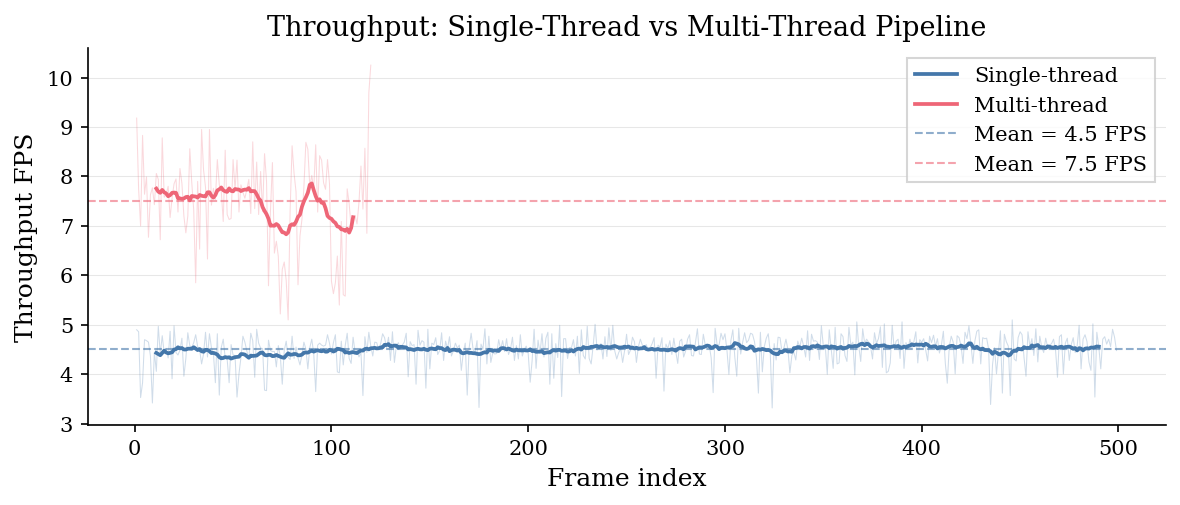

In [44]:
fig, ax = plt.subplots(figsize=(8, 3.5))

# Raw traces (faded)
ax.plot(df_st['frame_index'], df_st['throughput_fps'],
        color=C_BLUE, lw=0.5, alpha=0.25)
ax.plot(df_mt['frame_index'], df_mt['throughput_fps'],
        color=C_RED, lw=0.5, alpha=0.25)

# Rolling average
w = 20
ax.plot(df_st['frame_index'],
        df_st['throughput_fps'].rolling(w, center=True).mean(),
        color=C_BLUE, lw=1.8, label='Single-thread')
ax.plot(df_mt['frame_index'],
        df_mt['throughput_fps'].rolling(w, center=True).mean(),
        color=C_RED, lw=1.8, label='Multi-thread')

# Mean lines
mean_st = df_st['throughput_fps'].mean()
mean_mt = df_mt['throughput_fps'].mean()
ax.axhline(mean_st, color=C_BLUE, ls='--', lw=1, alpha=0.6,
           label=f'Mean = {mean_st:.1f} FPS')
ax.axhline(mean_mt, color=C_RED, ls='--', lw=1, alpha=0.6,
           label=f'Mean = {mean_mt:.1f} FPS')

ax.set_xlabel('Frame index')
ax.set_ylabel('Throughput FPS')
ax.set_title('Throughput: Single-Thread vs Multi-Thread Pipeline')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc',
          loc='upper right')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('throughput_comparison.png', bbox_inches='tight')
plt.show()

## 4 &ensp; Latency Over Time

Per-frame latency (wall-clock time from frame creation in the producer to
completion of visualisation) plotted against frame index.

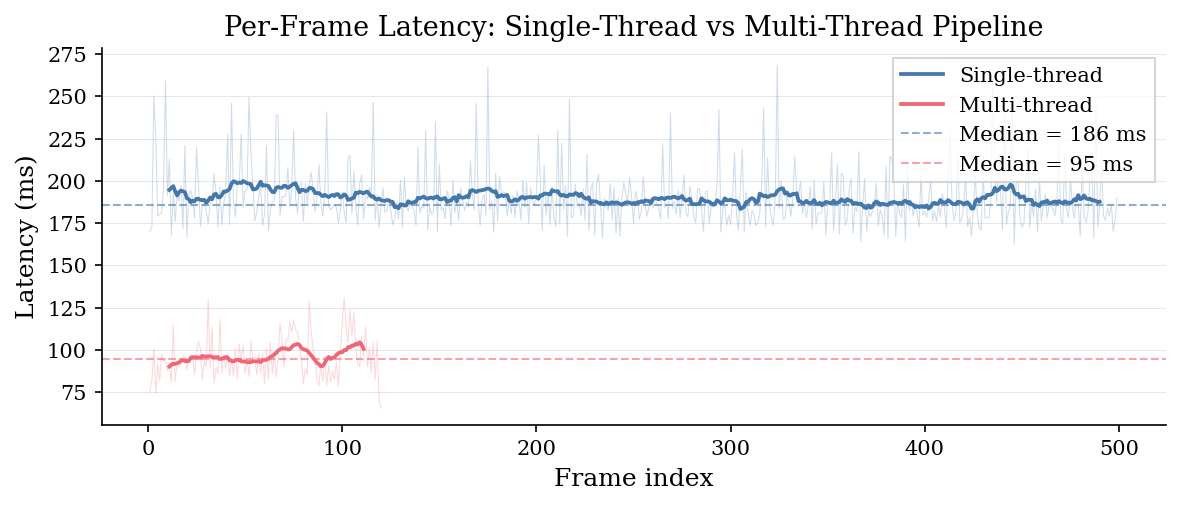

In [45]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(df_st['frame_index'], df_st['latency_ms'],
        color=C_BLUE, lw=0.5, alpha=0.25)
ax.plot(df_mt['frame_index'], df_mt['latency_ms'],
        color=C_RED, lw=0.5, alpha=0.25)

w = 20
ax.plot(df_st['frame_index'],
        df_st['latency_ms'].rolling(w, center=True).mean(),
        color=C_BLUE, lw=1.8, label='Single-thread')
ax.plot(df_mt['frame_index'],
        df_mt['latency_ms'].rolling(w, center=True).mean(),
        color=C_RED, lw=1.8, label='Multi-thread')

med_st = df_st['latency_ms'].median()
med_mt = df_mt['latency_ms'].median()
ax.axhline(med_st, color=C_BLUE, ls='--', lw=1, alpha=0.6,
           label=f'Median = {med_st:.0f} ms')
ax.axhline(med_mt, color=C_RED, ls='--', lw=1, alpha=0.6,
           label=f'Median = {med_mt:.0f} ms')

ax.set_xlabel('Frame index')
ax.set_ylabel('Latency (ms)')
ax.set_title('Per-Frame Latency: Single-Thread vs Multi-Thread Pipeline')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc',
          loc='upper right')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('latency_comparison.png', bbox_inches='tight')
plt.show()

## 5 &ensp; Distribution Analysis

Kernel density estimates (KDE) and box plots for both latency and throughput
distributions, enabling visual comparison of central tendency and dispersion.

/tmp/ipykernel_66147/415589966.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_66147/415589966.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


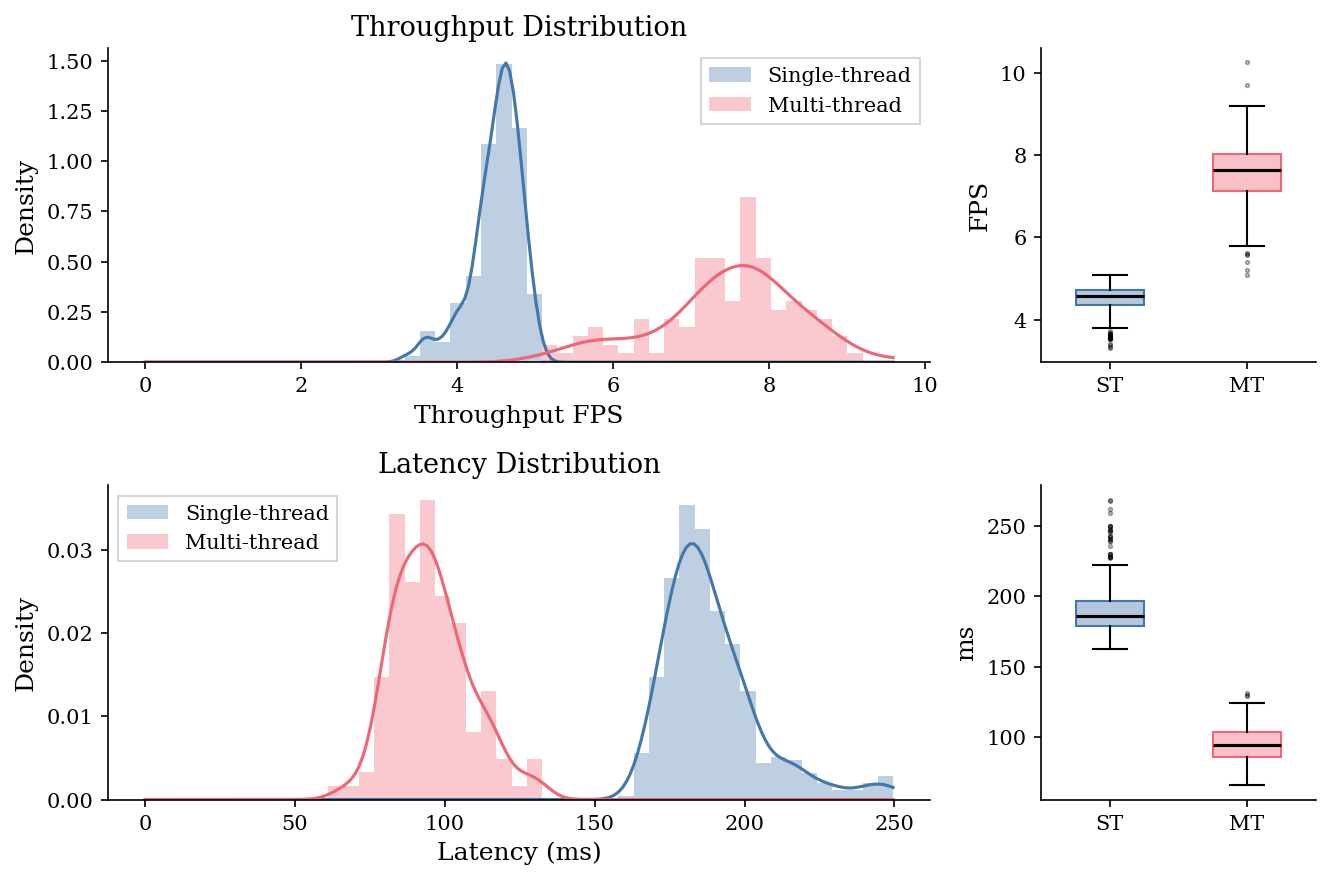

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6),
                         gridspec_kw={'width_ratios': [3, 1]})

# --- Row 0: Throughput ---
# KDE
ax = axes[0, 0]
bins = np.linspace(0,
    max(df_st['throughput_fps'].quantile(0.99),
        df_mt['throughput_fps'].quantile(0.99)), 50)
ax.hist(df_st['throughput_fps'], bins=bins, density=True,
        color=C_BLUE, alpha=0.35, edgecolor='none', label='Single-thread')
ax.hist(df_mt['throughput_fps'], bins=bins, density=True,
        color=C_RED, alpha=0.35, edgecolor='none', label='Multi-thread')

# KDE curves
from scipy.stats import gaussian_kde
x_range = np.linspace(bins[0], bins[-1], 200)
kde_st = gaussian_kde(df_st['throughput_fps'].dropna())
kde_mt = gaussian_kde(df_mt['throughput_fps'].dropna())
ax.plot(x_range, kde_st(x_range), color=C_BLUE, lw=1.5)
ax.plot(x_range, kde_mt(x_range), color=C_RED, lw=1.5)
ax.set_xlabel('Throughput FPS')
ax.set_ylabel('Density')
ax.set_title('Throughput Distribution')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')

# Box plot
ax = axes[0, 1]
bp = ax.boxplot(
    [df_st['throughput_fps'].dropna(), df_mt['throughput_fps'].dropna()],
    labels=['ST', 'MT'], widths=0.5, patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.4))
bp['boxes'][0].set_facecolor(C_BLUE + '66')
bp['boxes'][1].set_facecolor(C_RED + '66')
bp['boxes'][0].set_edgecolor(C_BLUE)
bp['boxes'][1].set_edgecolor(C_RED)
ax.set_ylabel('FPS')

# --- Row 1: Latency ---
# KDE
ax = axes[1, 0]
bins_lat = np.linspace(0,
    max(df_st['latency_ms'].quantile(0.99),
        df_mt['latency_ms'].quantile(0.99)), 50)
ax.hist(df_st['latency_ms'], bins=bins_lat, density=True,
        color=C_BLUE, alpha=0.35, edgecolor='none', label='Single-thread')
ax.hist(df_mt['latency_ms'], bins=bins_lat, density=True,
        color=C_RED, alpha=0.35, edgecolor='none', label='Multi-thread')

kde_st_lat = gaussian_kde(df_st['latency_ms'].dropna())
kde_mt_lat = gaussian_kde(df_mt['latency_ms'].dropna())
x_lat = np.linspace(bins_lat[0], bins_lat[-1], 200)
ax.plot(x_lat, kde_st_lat(x_lat), color=C_BLUE, lw=1.5)
ax.plot(x_lat, kde_mt_lat(x_lat), color=C_RED, lw=1.5)
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Density')
ax.set_title('Latency Distribution')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')

# Box plot
ax = axes[1, 1]
bp = ax.boxplot(
    [df_st['latency_ms'].dropna(), df_mt['latency_ms'].dropna()],
    labels=['ST', 'MT'], widths=0.5, patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.4))
bp['boxes'][0].set_facecolor(C_BLUE + '66')
bp['boxes'][1].set_facecolor(C_RED + '66')
bp['boxes'][0].set_edgecolor(C_BLUE)
bp['boxes'][1].set_edgecolor(C_RED)
ax.set_ylabel('ms')

plt.tight_layout()
plt.savefig('distribution_analysis.png', bbox_inches='tight')
plt.show()

## 6 &ensp; Statistical Testing

We apply a two-sided Mann–Whitney *U* test (non-parametric) to assess whether
the throughput and latency distributions differ significantly between the two
implementations.

In [47]:
# Throughput comparison
u_thr, p_thr = stats.mannwhitneyu(
    df_mt['throughput_fps'].dropna(),
    df_st['throughput_fps'].dropna(),
    alternative='two-sided')

# Latency comparison
u_lat, p_lat = stats.mannwhitneyu(
    df_mt['latency_ms'].dropna(),
    df_st['latency_ms'].dropna(),
    alternative='two-sided')

# Effect size (rank-biserial correlation)
n1_thr = len(df_mt['throughput_fps'].dropna())
n2_thr = len(df_st['throughput_fps'].dropna())
r_thr = 1 - (2 * u_thr) / (n1_thr * n2_thr)

n1_lat = len(df_mt['latency_ms'].dropna())
n2_lat = len(df_st['latency_ms'].dropna())
r_lat = 1 - (2 * u_lat) / (n1_lat * n2_lat)

print('Statistical Comparison (Mann–Whitney U test)')
print('=' * 55)
print(f'Throughput:  U = {u_thr:.0f},  p = {p_thr:.2e},  r = {r_thr:+.3f}')
print(f'Latency:     U = {u_lat:.0f},  p = {p_lat:.2e},  r = {r_lat:+.3f}')
print()
print(f'Throughput gain: {df_mt["throughput_fps"].median():.1f} vs '
      f'{df_st["throughput_fps"].median():.1f} FPS '
      f'({df_mt["throughput_fps"].median() / df_st["throughput_fps"].median():.2f}×)')
print(f'Latency cost:    {df_mt["latency_ms"].median():.0f} vs '
      f'{df_st["latency_ms"].median():.0f} ms '
      f'({df_mt["latency_ms"].median() / df_st["latency_ms"].median():.2f}×)')

Statistical Comparison (Mann–Whitney U test)
Throughput:  U = 59880,  p = 5.63e-65,  r = -1.000
Latency:     U = 0,  p = 5.69e-65,  r = +1.000

Throughput gain: 7.6 vs 4.6 FPS (1.67×)
Latency cost:    95 vs 186 ms (0.51×)


## 7 &ensp; Speedup & Efficiency Summary

A single visual summarising the key trade-off: throughput gain vs latency cost.

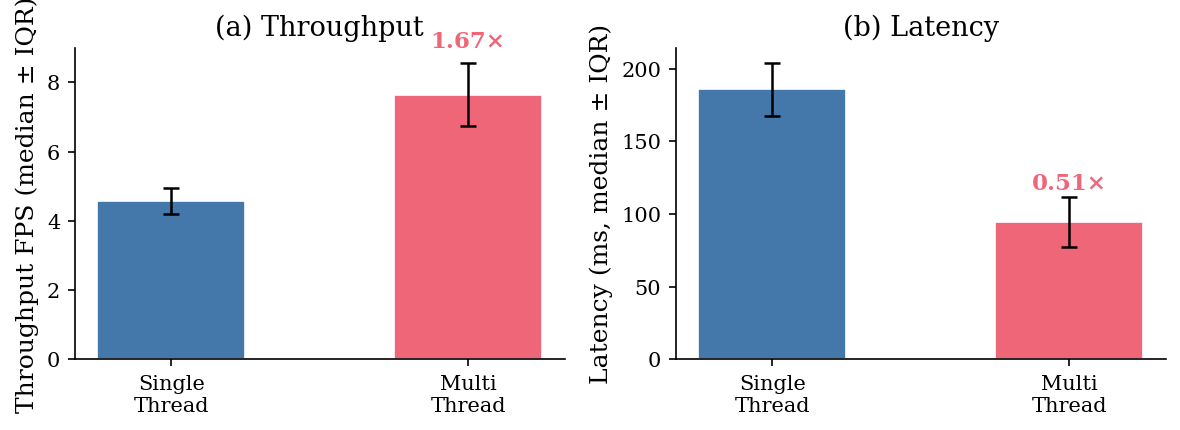

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# --- Panel A: Throughput bar chart ---
medians_thr = [df_st['throughput_fps'].median(),
               df_mt['throughput_fps'].median()]
iqrs_thr = [df_st['throughput_fps'].quantile(0.75) - df_st['throughput_fps'].quantile(0.25),
            df_mt['throughput_fps'].quantile(0.75) - df_mt['throughput_fps'].quantile(0.25)]

bars1 = ax1.bar(['Single\nThread', 'Multi\nThread'], medians_thr,
               yerr=iqrs_thr, capsize=4, width=0.5,
               color=[C_BLUE, C_RED], edgecolor='white', lw=0.8,
               error_kw=dict(lw=1.2, capthick=1.2))
ax1.set_ylabel('Throughput FPS (median ± IQR)')
ax1.set_title('(a) Throughput')

# Annotate speedup
speedup = medians_thr[1] / medians_thr[0]
ax1.annotate(f'{speedup:.2f}×',
             xy=(1, medians_thr[1] + iqrs_thr[1] + 0.3),
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             color=C_RED)

# --- Panel B: Latency bar chart ---
medians_lat = [df_st['latency_ms'].median(),
               df_mt['latency_ms'].median()]
iqrs_lat = [df_st['latency_ms'].quantile(0.75) - df_st['latency_ms'].quantile(0.25),
            df_mt['latency_ms'].quantile(0.75) - df_mt['latency_ms'].quantile(0.25)]

bars2 = ax2.bar(['Single\nThread', 'Multi\nThread'], medians_lat,
               yerr=iqrs_lat, capsize=4, width=0.5,
               color=[C_BLUE, C_RED], edgecolor='white', lw=0.8,
               error_kw=dict(lw=1.2, capthick=1.2))
ax2.set_ylabel('Latency (ms, median ± IQR)')
ax2.set_title('(b) Latency')

# Annotate cost
cost = medians_lat[1] / medians_lat[0]
ax2.annotate(f'{cost:.2f}×',
             xy=(1, medians_lat[1] + iqrs_lat[1] + 2),
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             color=C_RED)

plt.tight_layout()
plt.savefig('speedup_summary.png', bbox_inches='tight')
plt.show()

## 8 &ensp; Frame Drop Analysis

The multi-threaded pipeline uses a **conflated queue** that drops stale frames
when the AI cannot keep pace with the camera (simulated at 30 FPS).
This section quantifies the frame drop rate.

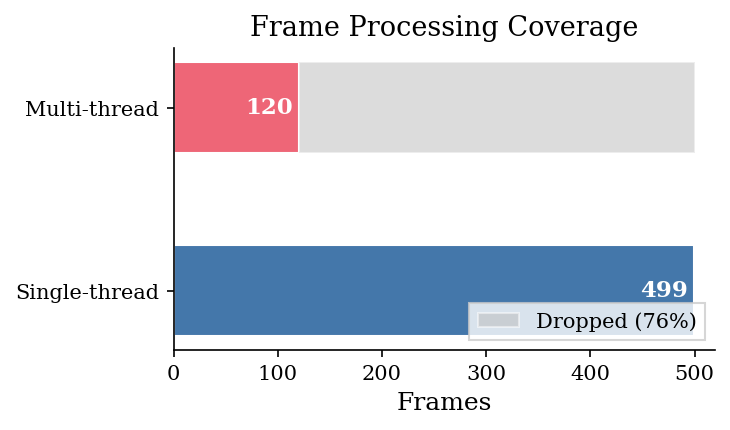

Single-thread: processed 499/500 frames (100%)
Multi-thread:  processed 120/500 frames (24.0%), dropped 380 (76.0%)


In [49]:
total_frames = 500
processed_st = len(df_st)
processed_mt = len(df_mt)

dropped = total_frames - processed_mt
drop_rate = dropped / total_frames * 100

fig, ax = plt.subplots(figsize=(5, 3))

bars = ax.barh(['Single-thread', 'Multi-thread'],
               [processed_st, processed_mt],
               color=[C_BLUE, C_RED], edgecolor='white', height=0.5)

# Dropped region for multi-thread
ax.barh(['Multi-thread'], [dropped], left=[processed_mt],
        color=C_GREY, edgecolor='white', height=0.5, alpha=0.5,
        label=f'Dropped ({drop_rate:.0f}%)')

ax.set_xlabel('Frames')
ax.set_title('Frame Processing Coverage')

# Annotate counts
for bar, val in zip(bars, [processed_st, processed_mt]):
    ax.text(val - 5, bar.get_y() + bar.get_height() / 2,
            f'{val}', ha='right', va='center', fontweight='bold',
            color='white', fontsize=11)

ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc',
          loc='lower right')
ax.set_xlim(0, total_frames + 20)
plt.tight_layout()
plt.savefig('frame_drop_analysis.png', bbox_inches='tight')
plt.show()

print(f'Single-thread: processed {processed_st}/{total_frames} frames (100%)')
print(f'Multi-thread:  processed {processed_mt}/{total_frames} frames '
      f'({processed_mt/total_frames*100:.1f}%), dropped {dropped} ({drop_rate:.1f}%)')

## 9 &ensp; Conclusions

The pipelined architecture with conflated queues demonstrates a clear
**throughput–latency trade-off**:

1. **Throughput** improves significantly, as pipeline stages operate
   concurrently (detection overlaps with landmark estimation).
2. **Latency** increases due to queuing delays between pipeline stages.
3. **Frame drops** are an inherent consequence of the conflated queue
   design, which prioritises freshness over completeness.

For **offline/batch** processing, the blocking-queue variant (processing
all frames) is preferable. For **real-time** applications, the conflated
queue ensures the system always operates on the latest available frame,
at the cost of processing only a subset of the input.

## Pipeline Stage Processing Times

The following plot analyzes the time taken by individual pipeline stages. It helps to identify the bottlenecks within the concurrent pipeline.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def get_data_path(filename):
    if os.path.exists(filename):
        return filename
    return f"../{filename}"

# Load pipeline stage metrics
df_stages = pd.read_csv(get_data_path('pipeline_stage_metrics.csv'))

fig, ax = plt.subplots(figsize=(8, 5))

# Prepare data for plotting
stages = df_stages['stage'].unique()
data = [df_stages[df_stages['stage'] == stage]['duration_ms'].dropna() for stage in stages]

# Create box plot matching the notebook style
bp = ax.boxplot(
    data,
    labels=stages,
    vert=False,
    widths=0.6,
    patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.4)
)

# Use the notebook's color palette
colors = [C_BLUE, C_CYAN, C_GREEN, C_YELLOW, C_PURPLE, C_RED]
for i, box in enumerate(bp['boxes']):
    c = colors[i % len(colors)]
    box.set_facecolor(c + '66')
    box.set_edgecolor(c)

ax.set_title('Processing Time per Pipeline Stage')
ax.set_xlabel('Duration (ms)')
ax.set_ylabel('Pipeline Stage')
ax.xaxis.grid(True)

plt.tight_layout()
plt.savefig('pipeline_stages_boxplot.png', bbox_inches='tight')
plt.show()

# Display summary statistics
summary = df_stages.groupby('stage')['duration_ms'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
display(summary.sort_values('mean', ascending=False))

FileNotFoundError: [Errno 2] No such file or directory: '../pipeline_stage_metrics.csv'

In [ ]:
import os
print(os.listdir(os.getcwd()))

['notebooks', 'output', '.git', 'fps_metrics_multithread.csv', '.gitignore', '.idea', 'tools', 'src', 'target', 'pom.xml', 'fps_metrics_single_thread.csv']
